<a href="https://colab.research.google.com/github/Anurag636418/learn-neural-networks-nn/blob/main/train_small_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential

In [2]:
import random
random.seed(2)

import tensorflow as tf
tf.random.set_seed(2)

import numpy as np
np.random.seed(2)

In [3]:
bad_pizza_dataset = pd.DataFrame.from_dict({
        'tomato_sauce': ['no', 'no', 'yes', 'yes'],
        'barbecue_sauce': ['no', 'yes', 'no', 'yes'],
        'result': ['sauce error', 'good', 'good', 'sauce error']
    }
)

In [4]:
bad_pizza_dataset

,tomato_sauce,barbecue_sauce,result
0,no,no,sauce error
1,no,yes,good
2,yes,no,good
3,yes,yes,sauce error


In [5]:
bad_pizza_dataset['c_tomato_sauce'] = bad_pizza_dataset['tomato_sauce'].apply(lambda x: 1 if x == 'yes' else 0)
bad_pizza_dataset['c_barbecue_sauce'] = bad_pizza_dataset['barbecue_sauce'].apply(lambda x: 1 if x == 'yes' else 0)
bad_pizza_dataset['c_result'] = bad_pizza_dataset['result'].apply(lambda x: 1 if x == 'sauce error' else 0)

In [ ]:
bad_pizza_dataset


,tomato_sauce,barbecue_sauce,result,c_tomato_sauce,c_barbecue_sauce,c_result
0,no,no,sauce error,0,0,1
1,no,yes,good,0,1,0
2,yes,no,good,1,0,0
3,yes,yes,sauce error,1,1,1


<Axes: xlabel='c_tomato_sauce', ylabel='c_barbecue_sauce'>

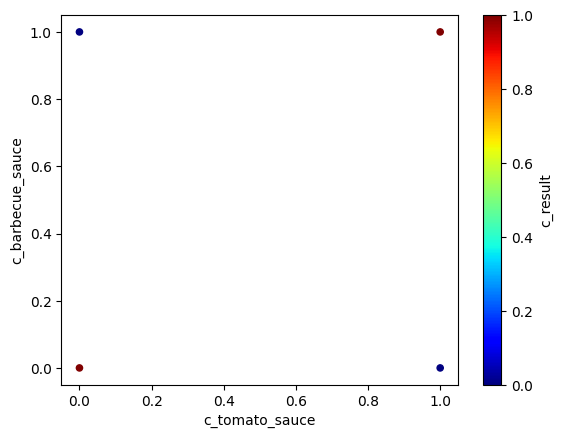

In [6]:
bad_pizza_dataset.plot(
    kind='scatter',
    x='c_tomato_sauce',
    y='c_barbecue_sauce',
    c='c_result',
    colormap='jet'
)

In [7]:
input_layer=Dense(units=2,input_dim=2,activation='sigmoid')
output_layer=Dense(units=1,activation='sigmoid')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
bad_pizza_model=Sequential()
bad_pizza_model.add(input_layer)
bad_pizza_model.add(output_layer)
sgd=SGD(learning_rate=1.0)
bad_pizza_model.compile(loss='binary_crossentropy',optimizer=sgd,metrics=['accuracy'])


In [9]:
bad_pizza_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_model=bad_pizza_model.fit(
    bad_pizza_dataset[['c_tomato_sauce','c_barbecue_sauce']],
    bad_pizza_dataset['c_result'],
    epochs=1000
)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step - accuracy: 0.5000 - loss: 0.7010
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 0.7004
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.7000
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.6996
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6993
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6990
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.6986
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6983
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6981
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.6978
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.6975
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy

In [15]:
test_loss, test_acc = bad_pizza_model.evaluate(
bad_pizza_dataset[['c_tomato_sauce', 'c_barbecue_sauce']],
bad_pizza_dataset['c_result']
)

print(f"Evaluation result on Test Data : Loss = {test_loss}, accuracy = {test_acc}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 0.0138
Evaluation result on Test Data : Loss = 0.013776139356195927, accuracy = 1.0


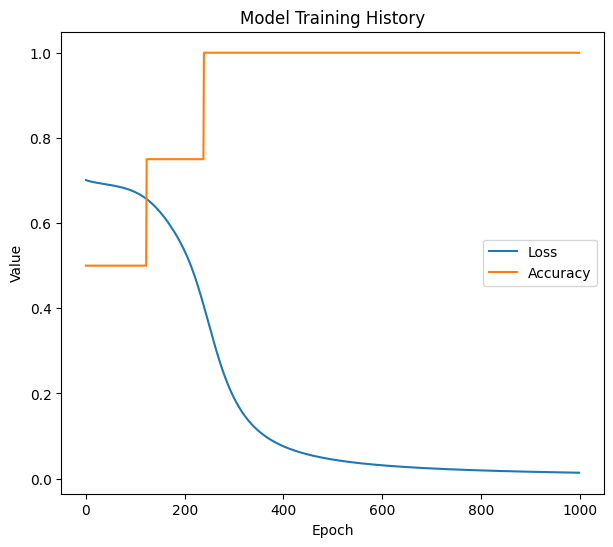

In [16]:
plt.figure(figsize=(7, 6))
plt.plot(history_model.history['loss'])
plt.plot(history_model.history['accuracy'])
plt.title('Model Training History')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend(['Loss', 'Accuracy'], loc='center right')
plt.show()